In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pulp import *
from scipy.spatial.distance import cdist
from matplotlib.patches import Rectangle

In [2]:
print(listSolvers(onlyAvailable=True))
solver = GUROBI(msg=True)
print("Gurobi disponible:", solver.available())

['GUROBI', 'GUROBI_CMD', 'PULP_CBC_CMD']
Set parameter Username
Set parameter LicenseID to value 2847302
Academic license - for non-commercial use only - expires 2027-07-21
Gurobi disponible: True


In [14]:
#Parámetros del problema
m=10 #Número de usuarios
n=5 #Número máximo de médicos
dt=10 #Tiempo en minutos
K=144 #Número de intervalos de Tiempo
velocidad=30 #En unidades de km/hora
r=np.random.uniform(low=0, high=30, size=(m,2)) #Posiciones de los usuarios
H=12 #Horas de un turno de un médico
beta=int(H*60/dt) #Numero máximo de turnos seguidos por un médico, 
Cmed=25000*H
distancias = cdist(r, r)
delta=distancias/velocidad*60 #Matriz de distancias en minutos
delta=np.ceil(delta/dt) #Matriz de distancias en intervalos de tiempo
delta={(i+1,j+1):delta[i,j] for i in range(0,m) for j in range(0,m)}
costo=distancias*600 #Costo de $600 por km de recorrido
costo={(i+1,j+1):costo[i,j] for i in range(0,m) for j in range(0,m)}
#Agregaremos los nodos de origen S y destino T, por ahora con valores 0 en tiempo y costo
for i in range(1,m+1):
    delta['S',i]=0
    delta[i,'T']=0
    costo['S',i]=0
    costo[i,'T']=0
#Generación de parámetros de servicio de los pacientes
a={i:np.random.randint(low=1, high=K-10) for i in range(1,m+1)} #Tiempo de llegada de los usuarios
b={}
c={}
for i in range(1,m+1):
    ventana=np.random.randint(low=4, high=20) #Duración de la ventana de servicio
    ventana=min(144-a[i]-1, ventana)
    b[i]=a[i]+ventana+1
    duracion=np.random.randint(low=1, high=b[i]-a[i])
    c[i]=duracion

#Parámetros auxiliares para construir las ecuaciones
alfa={}
tau={i:[] for i in range(1,m+1)}
for i in range(1,m+1):
    for k in range(1, K+1):
        if(k>=a[i] and k<=b[i]-c[i]+1):
            alfa[i,k]=1
            tau[i].append(k)
        else:
            alfa[i,k]=0
Mt=K

In [ ]:
prob=LpProblem('Optimizacion_turnos_horarios_atencion', LpMinimize) #Dado que importamos toda la librería de Pulp
#Construccion de variables

# Inicio de atención de pacientes
x={}
for i in range(1,m+1):
    for j in range(1, n+1):
        for k in range(1,K+1):
            if(alfa[i,k]==1): 
                x[i,j,k]=LpVariable(f'Us{i}_Dr{j}_Time{k}', cat=LpBinary)

# Uso de médico j en algun momento:
u={j:LpVariable('Doctor_'+str(j)+'_activo', cat=LpBinary) for j in range(1,n+1)}

# Comienzo del turno del médico j en un momento k:
y={(j,k):LpVariable('Doctor_'+str(j)+'_'+str(k), cat=LpBinary) for j in range(1,n+1) for k in range(1,K+1-beta)}

# ti, tiempo en que comienza el servicio del paciente, es una expresión para utilizar más adelante
# ti=lpSum([k*x[i,j,k] for j in range(1, n+1) for k in tau[i]])

# qj, tiempo en que comienza el turno el médico j, es una expresión para utilizar más adelante
# qj=lpSum([k*y[j,k] for k in range(1,K+1-beta)])

#orden de los pacientes con un mismo médico
z={}
for j in range(1,n+1):
    for a in range(1,m+1):
        z['S',a,j]=LpVariable(f'Z_S_{a}_{j}', cat=LpBinary)
        z[a,'T',j]=LpVariable(f'Z_{a}_T_{j}', cat=LpBinary)
                
        for b in range(1,m+1):
            if(a!=b):
                z[a,b,j]=LpVariable(f'Z_{a}_{b}_{j}', cat=LpBinary)

#Función objetivo
suma=lpSum([Cmed*u[j] for j in range(1,n+1)])
for j in range(1,n+1): #Para todos los médicos
    for a in list(range(1,m+1))+['S']: #Nodos de origen
        for b in list(range(1,m+1))+['T']: #Nodos de destino
            if(a!=b):
                if(not(a=='S' and b=='T')):
                    suma+=costo[a,b]*z[a,b,j]
prob+=suma, 'Función objetivo'

#1. Restricción
for i in range(1,m+1):
    prob+=lpSum([x[i,j,k] for j in range(1,n+1) for k in tau[i]])==1

#2. Restricción
for i in range(1,m+1):
    for j in range(1,n+1):
        prob+=lpSum([x[i,j,k] for k in tau[i]])<=u[j]

#3. Restricción
for j in range(1,n+1):
    prob+=lpSum([y[j,k] for k in range(1,K+1-beta)])==u[j]

#4. 
for i in range(1,m+1):
    for j in range(1, n+1):
        for k in tau[i]:
            suma=0
            for s in range(1,K+1-beta):
                if(s<=k and k+c[i]<=s+beta):
                    suma+=y[j,s]
            prob+=x[i,j,k]<=suma

#5. y 6. 
for j in range(1, n+1):
    prob+=lpSum([z['S',i,j] for i in range(1,m+1)])==u[j]
    prob+=lpSum([z[i,'T',j] for i in range(1,m+1)])==u[j]

#7. y 8.
for i in range(1,m+1):
    for j in range(1,n+1):
        prob+=z['S',i,j]+lpSum([z[a,i,j] for a in range(1,m+1) if a!=i])==lpSum([x[i,j,k] for k in tau[i]])
        prob+=z[i,'T',j]+lpSum([z[i,b,j] for b in range(1,m+1) if b!=i])==lpSum([x[i,j,k] for k in tau[i]])
        
#9. 
for j in range(1, n+1):
    for a in range(1, m+1):
        for b in range(1, m+1):
            if(a!=b):
                prob+=lpSum([k*x[b,j,k] for j in range(1, n+1) for k in tau[b]])>=lpSum([k*x[a,j,k] for j in range(1, n+1) for k in tau[a]])+\
                c[a]+delta[a,b]-Mt*(1-z[a,b,j])

#10. y 11.
for i in range(1,m+1):
    for j in range(1,n+1):
        prob+=lpSum([k*x[i,j,k] for j in range(1, n+1) for k in tau[i]])>=lpSum([k*y[j,k] for k in range(1,K+1-beta)])+\
            delta['S',i]-Mt*(1-z['S',i,j])
        prob+=lpSum([k*x[i,j,k] for j in range(1, n+1) for k in tau[i]])+c[i]+delta[i,'T']<=\
            lpSum([k*y[j,k] for k in range(1,K+1-beta)]) +beta+Mt*(1-z[i,'T',j])

#12. 
for j in range(1, n):
    prob+=u[j]>=u[j+1]

prob

In [ ]:
solver = GUROBI(
    msg=True,
    timeLimit=400,
    gapRel=0.001
)
prob.solve(solver)


Set parameter Username
Set parameter LicenseID to value 2847302
Academic license - for non-commercial use only - expires 2027-07-21
Set parameter TimeLimit to value 400
Set parameter MIPGap to value 0.001
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 5825U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  400
MIPGap  0.001

Optimize a model with 1104 rows, 1290 columns and 58048 nonzeros (Min)
Model fingerprint: 0xc7efa4c5
Model has 455 linear objective coefficients
Variable types: 0 continuous, 1290 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+02]
  Objective range  [9e+02, 3e+05]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+02]

Presolve removed 477 rows and 347 columns
Presolve time: 0.09s
Presolved: 627 rows, 943 columns, 14356 nonzeros
Variable types: 0 conti

1

In [23]:
#Revisión de las variables
#Enrutamiento
for j in range(1,n+1):
    for key,var in z.items():
        a,b,jo=key
        if(jo==j and var.varValue>0):
            print(var)
#Inicios de atención
for i in range(1,m+1):
    for key,var in x.items():
            io,j,k=key
            if(io==i and var.varValue>0):
                print(var)
#Inicios de turnos
for k,var in y.items():
    if(var.varValue>0):
         print(var)

Z_S_5_1
Z_5_T_1
Z_1_9_2
Z_S_2_2
Z_2_1_2
Z_4_T_2
Z_9_4_2
Z_3_T_3
Z_S_8_3
Z_8_3_3
Z_6_T_4
Z_7_6_4
Z_S_10_4
Z_10_7_4
Us1_Dr2_Time29
Us2_Dr2_Time22
Us3_Dr3_Time136
Us4_Dr2_Time51
Us5_Dr1_Time111
Us6_Dr4_Time105
Us7_Dr4_Time91
Us8_Dr3_Time123
Us9_Dr2_Time34
Us10_Dr4_Time39
Doctor_1_55
Doctor_2_22
Doctor_3_69
Doctor_4_39


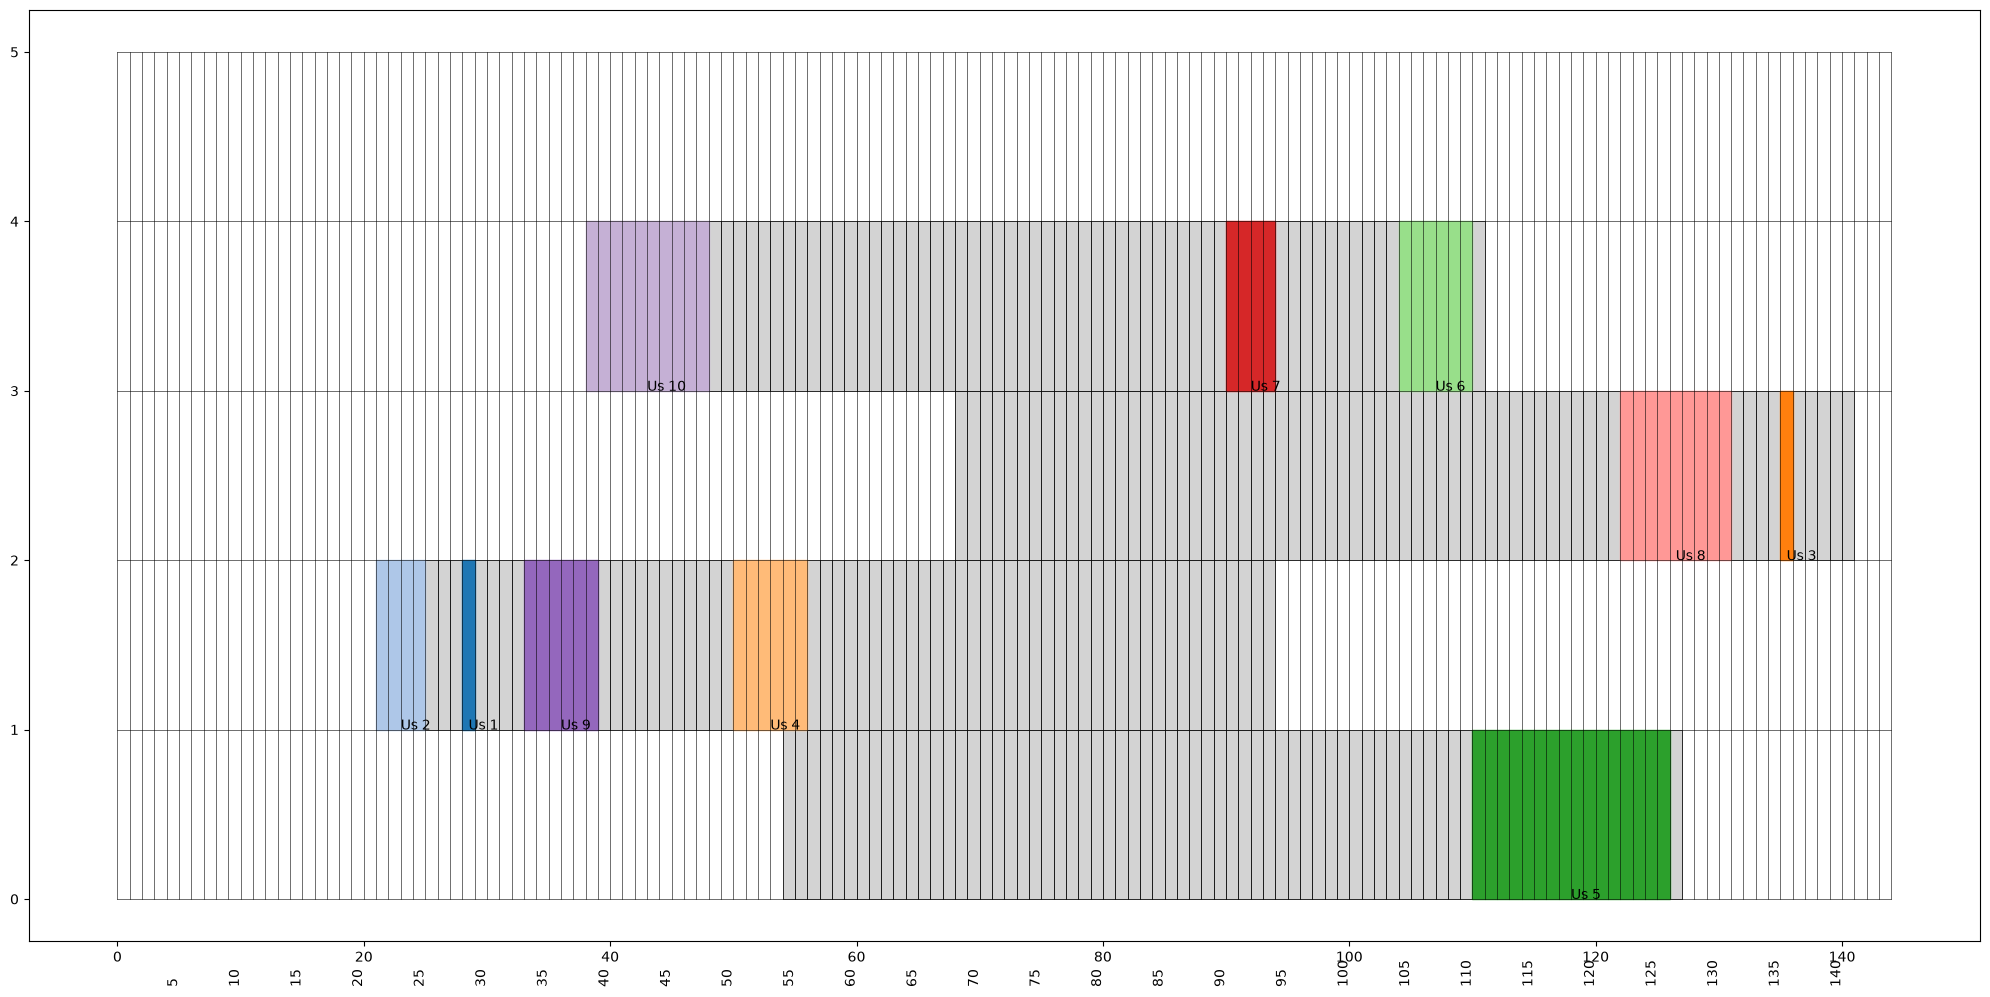

In [24]:
#Visualización del resultado
cmap = plt.get_cmap('tab20')
colors = [cmap(i % cmap.N) for i in range(m+1)] #Para cada paciente o usuario

plt.figure(figsize=(20,10))
ax=plt.gca()
lw=0.4
for j in range(0, n+1):
    plt.plot([0,K],[j,j], '-k', linewidth=lw)
    if(i<=n-1):
        plt.text(-4,i,str(j+1))
for k in range(0, K+1):
    plt.plot([k,k],[0,n], '-k', linewidth=lw)
    if(k<=K-1 and (k+1)%5==0):
        plt.text(k,-0.5,str(k+1), fontsize=10, rotation=90)

for j in range(1,n+1):
    if(u[j].varValue>0): #El doctor está activo
        for k in range(1,K+1-beta):
            if(y[j,k].varValue>0): #Tiempo de arranque del médico en su turno
                inicio=k
        for k in range(inicio, min(inicio+beta+1, K)):
            rect = Rectangle(
                (k-1,j-1),          # esquina inferior izquierda (x,y)
                1,               # ancho
                1,             # alto
                facecolor='lightgray', # color de relleno
                edgecolor='black', # borde
                linewidth=lw
            )
            ax.add_patch(rect)
            
for key,v in x.items():
    if(v.varValue>0):
        i,j,k=key
        for ni in range(0,c[i]):
            rect = Rectangle(
                (k-1+ni, j-1),          # esquina inferior izquierda (x,y)
                1,               # ancho
                1,             # alto
                facecolor=colors[i-1], # color de relleno
                edgecolor=colors[i-1], # borde
                linewidth=1
            )

            ax.add_patch(rect)
        centro=k-1+c[i]/2
        plt.text(centro, j-1, f'Us {i}')
        
plt.tight_layout()